# Data Transformation and Feature Engineering

## Learning Objectives
- Understand how to transform raw data into features suitable for AI models.
- Learn techniques such as scaling, encoding categorical variables, and feature creation.

## Introduction
Raw data often needs to be transformed and engineered into meaningful features that improve model performance. This notebook introduces common preprocessing and feature engineering techniques.

## Core Concepts

- Scaling and Normalization: Many machine learning algorithms are sensitive to the scale of input features. This step adjusts the range of features to a common scale.
    - Min-Max Scaling (Normalization): Rescales features to a fixed range, usually 0 to 1. It's calculated as: (value - min) / (max - min).
    - Standardization (Z-score Normalization): Rescales features to have a mean of 0 and a standard deviation of 1. It's calculated as: (value - mean) / std_dev. This is less affected by outliers than Min-Max scaling.

- Encoding Categorical Data: Machine learning models require numerical inputs, so text-based categories must be converted.
    - One-Hot Encoding: Creates a new binary (0 or 1) column for each category. This is the most common approach as it doesn't create a false sense of order between categories. For example, a "color" column with "red" and "blue" becomes two columns: "is_red" and "is_blue".
    - Label Encoding: Assigns a unique integer to each category (e.g., red=0, blue=1). This is simpler but can mislead models into thinking there is an ordinal relationship (e.g., that blue is "greater" than red).

- Feature Creation: This is the art of engineering new, more informative features from the existing ones. For example, you could create an "age" feature from a "date_of_birth" column, or a "household_size" feature by combining "num_adults" and "num_children". This can provide the model with more powerful signals than the raw data alone.

- Dimensionality Reduction: This process reduces the number of input features (or dimensions) in a dataset. It helps to simplify models, reduce training time, and mitigate the "curse of dimensionality" (where performance degrades as features increase).
    - PCA (Principal Component Analysis): A technique that transforms the data into a new set of uncorrelated variables called principal components, which are ordered by the amount of variance they explain. You can then keep only the first few components to reduce dimensionality while retaining most of the information.
    - Feature Selection: Involves automatically or manually selecting the most relevant features and discarding the rest.


## Example
Basic scaling and encoding with scikit-learn.

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Sample data
data = {'Age': [25, 45, 35], 'City': ['New York', 'Los Angeles', 'New York']}
df = pd.DataFrame(data)
print("Original Data:")
print(df)

# Scale Age
scaler = MinMaxScaler()
df['Age_scaled'] = scaler.fit_transform(df[['Age']])

# One-hot encode City
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['City']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['City']))

# Combine and drop the original 'City' column
df = pd.concat([df.drop('City', axis=1), encoded_df], axis=1)

print("\nTransformed Data:")
print(df)

Original Data:
   Age         City
0   25     New York
1   45  Los Angeles
2   35     New York

Transformed Data:
   Age  Age_scaled  City_Los Angeles  City_New York
0   25         0.0               0.0            1.0
1   45         1.0               1.0            0.0
2   35         0.5               0.0            1.0


### Standard Scaller

Standardization is used to transform continuous data to normally distributed format. There are some cases where is required

* Models are linear
* Dataset features have high variance 

The StandardScaler uses normally distributed data and seeks to scale them such that the distribution is now centred around 0, with a standard deviation of 1.

<Axes: ylabel='Density'>

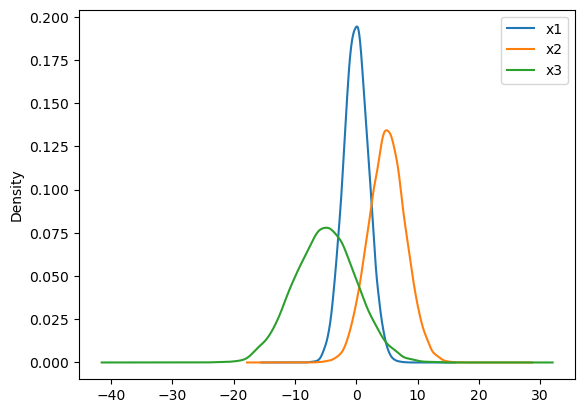

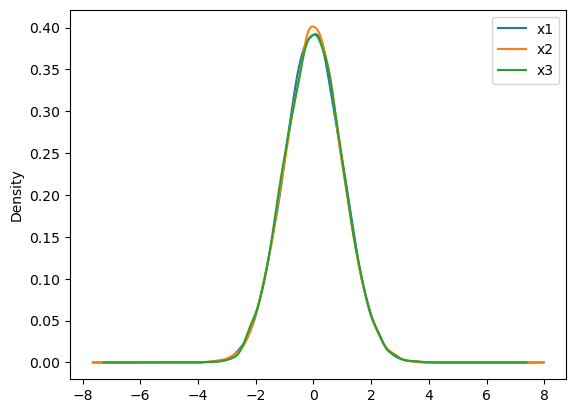

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
df = pd.DataFrame({
    'x1': np.random.normal(0, 2, 10000),
    'x2': np.random.normal(5, 3, 10000),
    'x3': np.random.normal(-5, 5, 10000)
})
df.plot.kde()
ss = StandardScaler()
data_tf = ss.fit_transform(df)
df = pd.DataFrame(data_tf, columns=['x1','x2','x3'])
df.plot.kde()


## Exercise
Try scaling the 'Age_scaled' column back to the original scale using inverse_transform.

In [ ]:
# Your code here

## Summary
- Proper data transformation and feature engineering are vital to model success.
- Techniques include scaling, encoding, and creating new features.


## Further Reading
- [Feature Engineering Guide](https://machinelearningmastery.com/discover-feature-engineering-how-to-engineer-features-and-prepare-data-for-machine-learning/)
- [scikit-learn Preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html)